# Task 3: NLP and Attention Mechanism

In this task, I implemented core attention-based sequence modeling techniques for machine translation.

The task is divided into four parts:
1. Scaled dot-product attention from scratch using NumPy
2. A seq2seq encoder-decoder model with attention
3. Machine translation on a small public dataset and BLEU evaluation
4. A simplified Transformer model for the same translation task

## Part 1: Scaled Dot-Product Attention from Scratch

Scaled dot-product attention computes attention scores between queries and keys, scales them by the square root of the key dimension, applies softmax to obtain attention weights, and then uses those weights to combine the values.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(12)

In [2]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = K.shape[1]
    scores = np.dot(Q, K.T) / np.sqrt(d_k)
    attention_weights = softmax(scores)
    output = np.dot(attention_weights, V)
    return output, attention_weights, scores

In [3]:
Q = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 1]
], dtype=np.float32)

K = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 1, 0, 0]
], dtype=np.float32)

V = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
], dtype=np.float32)

In [4]:
output, attention_weights, scores = scaled_dot_product_attention(Q, K, V)

print("Scaled Scores:\n", scores)
print("\nAttention Weights:\n", attention_weights)
print("\nAttention Output:\n", output)

Scaled Scores:
 [[1.  0.  0.5]
 [0.  1.  0.5]]

Attention Weights:
 [[0.50648039 0.18632372 0.30719589]
 [0.18632372 0.50648039 0.30719589]]

Attention Output:
 [[2.60143099 3.60143099]
 [3.24174432 4.24174432]]


In [5]:
scores_df = pd.DataFrame(scores, index=["Query 1", "Query 2"], columns=["Key 1", "Key 2", "Key 3"])
weights_df = pd.DataFrame(attention_weights, index=["Query 1", "Query 2"], columns=["Key 1", "Key 2", "Key 3"])
output_df = pd.DataFrame(output, index=["Query 1", "Query 2"], columns=["Value Dim 1", "Value Dim 2"])

display(scores_df)
display(weights_df)
display(output_df)

,Key 1,Key 2,Key 3
Query 1,1.0,0.0,0.5
Query 2,0.0,1.0,0.5


,Key 1,Key 2,Key 3
Query 1,0.506480,0.186324,0.307196
Query 2,0.186324,0.506480,0.307196


,Value Dim 1,Value Dim 2
Query 1,2.601431,3.601431
Query 2,3.241744,4.241744


## Part 2: Seq2Seq Model with Attention

In this part, I implemented an encoder-decoder sequence-to-sequence model with attention for machine translation.

The attention mechanism allows the decoder to focus on the most relevant encoder hidden states while generating each output token. This helps the model handle longer sequences more effectively than a basic seq2seq model without attention.

In [6]:
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cuda


### Small Translation Dataset

To develop and test the seq2seq attention model, I started with a small English–French parallel dataset. Later, in Part 3, the same architecture can be trained on a larger public dataset and evaluated with BLEU score.

In [7]:
from datasets import load_dataset
import re

print("Loading OPUS Books English-French dataset...")

dataset = load_dataset("opus_books", "en-fr", split="train")

def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9'?.!,;: -]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

sentence_pairs = []

for example in dataset:
    en = clean_text(example["translation"]["en"])
    fr = clean_text(example["translation"]["fr"])

    # keep reasonably short sentences for faster training
    if 1 <= len(en.split()) <= 12 and 1 <= len(fr.split()) <= 12:
        sentence_pairs.append((en, fr))

    if len(sentence_pairs) >= 10000:
        break

print("Number of sentence pairs:", len(sentence_pairs))
for i in range(5):
    print(sentence_pairs[i])

Loading OPUS Books English-French dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Number of sentence pairs: 10000
('the wanderer', 'le grand meaulnes')
('alain-fournier', 'alain-fournier')
('first part', 'première partie')
('i', 'chapitre premier')
('the boarder', 'le pensionnaire')


In [8]:
SPECIAL_TOKENS = ["<pad>", "<sos>", "<eos>", "<unk>"]

def tokenize(text):
    return text.lower().strip().split()

def build_vocab(sentences, min_freq=1):
    counter = Counter()
    for sentence in sentences:
        counter.update(tokenize(sentence))

    vocab = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
    idx = len(vocab)

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

src_sentences = [src for src, tgt in sentence_pairs]
tgt_sentences = [tgt for src, tgt in sentence_pairs]

src_vocab = build_vocab(src_sentences)
tgt_vocab = build_vocab(tgt_sentences)

idx_to_src = {idx: token for token, idx in src_vocab.items()}
idx_to_tgt = {idx: token for token, idx in tgt_vocab.items()}

print("Source vocab size:", len(src_vocab))
print("Target vocab size:", len(tgt_vocab))

Source vocab size: 12511
Target vocab size: 14319


In [9]:
def numericalize(sentence, vocab):
    tokens = ["<sos>"] + tokenize(sentence) + ["<eos>"]
    return [vocab.get(token, vocab["<unk>"]) for token in tokens]

pairs_numeric = [
    (numericalize(src, src_vocab), numericalize(tgt, tgt_vocab))
    for src, tgt in sentence_pairs
]

train_pairs, val_pairs = train_test_split(pairs_numeric, test_size=0.2, random_state=SEED)

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Example numeric source:", train_pairs[0][0])
print("Example numeric target:", train_pairs[0][1])

Train pairs: 8000
Validation pairs: 2000
Example numeric source: [1, 9, 743, 4, 9316, 55, 132, 628, 2]
Example numeric target: [1, 42, 9974, 183, 9975, 17, 464, 9976, 316, 9977, 2]


In [10]:
class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.pairs[idx][0], dtype=torch.long),
            torch.tensor(self.pairs[idx][1], dtype=torch.long)
        )

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_lengths = [len(x) for x in src_batch]
    tgt_lengths = [len(x) for x in tgt_batch]

    src_padded = nn.utils.rnn.pad_sequence(
        src_batch, batch_first=True, padding_value=src_vocab["<pad>"]
    )
    tgt_padded = nn.utils.rnn.pad_sequence(
        tgt_batch, batch_first=True, padding_value=tgt_vocab["<pad>"]
    )

    return src_padded, tgt_padded, src_lengths, tgt_lengths

train_dataset = TranslationDataset(train_pairs)
val_dataset = TranslationDataset(val_pairs)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

batch = next(iter(train_loader))
print("Source batch shape:", batch[0].shape)
print("Target batch shape:", batch[1].shape)

Source batch shape: torch.Size([8, 12])
Target batch shape: torch.Size([8, 14])


### Attention Mechanism

I used a dot-product style attention mechanism inside the decoder. At each decoding step, the decoder compares its current hidden state with all encoder outputs, computes attention weights, and forms a context vector as a weighted sum of encoder hidden states.

In [11]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=src_vocab["<pad>"])
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

In [12]:
class DotProductAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.scale = math.sqrt(hid_dim)

    def forward(self, decoder_hidden, encoder_outputs, mask=None):

        decoder_hidden = decoder_hidden.permute(1, 0, 2)  # [batch, 1, hid_dim]
        scores = torch.bmm(decoder_hidden, encoder_outputs.transpose(1, 2)) / self.scale

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(attention_weights, encoder_outputs)  # [batch, 1, hid_dim]

        return context, attention_weights

In [13]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=tgt_vocab["<pad>"])
        self.attention = DotProductAttention(hid_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim * 2 + emb_dim, output_dim)

    def forward(self, input_token, hidden, encoder_outputs):
        # input_token: [batch]
        input_token = input_token.unsqueeze(1)  # [batch, 1]
        embedded = self.embedding(input_token)  # [batch, 1, emb_dim]

        context, attention_weights = self.attention(hidden, encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(rnn_input, hidden)
        prediction = self.fc_out(torch.cat((output, context, embedded), dim=2)).squeeze(1)

        return prediction, hidden, attention_weights

In [14]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.embedding.num_embeddings

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src)

        input_token = tgt[:, 0]  # <sos>

        for t in range(1, tgt_len):
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs)
            outputs[:, t, :] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

In [15]:
INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)
EMB_DIM = 64
HID_DIM = 128

encoder = Encoder(INPUT_DIM, EMB_DIM, HID_DIM)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM)

seq2seq_model = Seq2Seq(encoder, decoder, device).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
optimizer = optim.Adam(seq2seq_model.parameters(), lr=0.001)

print(seq2seq_model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(12511, 64, padding_idx=0)
    (gru): GRU(64, 128, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(14319, 64, padding_idx=0)
    (attention): DotProductAttention()
    (gru): GRU(192, 128, batch_first=True)
    (fc_out): Linear(in_features=320, out_features=14319, bias=True)
  )
)


### Training Setup

The seq2seq model is trained using cross-entropy loss with padding ignored. Teacher forcing is used during training so that the decoder sometimes receives the true previous token instead of its own prediction, which helps stabilize learning.

In [16]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0

    for src, tgt, _, _ in dataloader:
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [17]:
def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt, _, _ in dataloader:
            src = src.to(device)
            tgt = tgt.to(device)

            output = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [18]:
num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_epoch(seq2seq_model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_epoch(seq2seq_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/10] | Train Loss: 6.8610 | Val Loss: 6.6424
Epoch [2/10] | Train Loss: 5.7369 | Val Loss: 6.6503
Epoch [3/10] | Train Loss: 4.9550 | Val Loss: 6.7914
Epoch [4/10] | Train Loss: 4.2066 | Val Loss: 6.9945
Epoch [5/10] | Train Loss: 3.5026 | Val Loss: 7.2114
Epoch [6/10] | Train Loss: 2.9157 | Val Loss: 7.4741
Epoch [7/10] | Train Loss: 2.5103 | Val Loss: 7.6916
Epoch [8/10] | Train Loss: 2.2105 | Val Loss: 7.9228
Epoch [9/10] | Train Loss: 1.9694 | Val Loss: 8.1032
Epoch [10/10] | Train Loss: 1.7332 | Val Loss: 8.2965


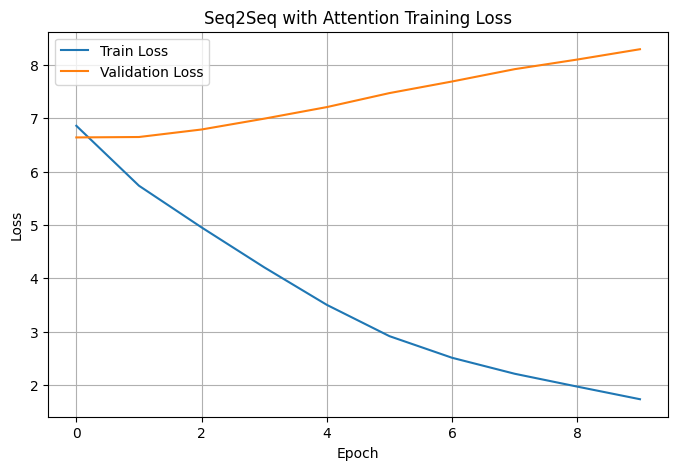

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq with Attention Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def translate_sentence(model, sentence, src_vocab, tgt_vocab, idx_to_tgt, device, max_len=20):
    model.eval()

    tokens = ["<sos>"] + tokenize(sentence) + ["<eos>"]
    src_indices = [src_vocab.get(token, src_vocab["<unk>"]) for token in tokens]
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    input_token = torch.tensor([tgt_vocab["<sos>"]], dtype=torch.long).to(device)
    generated_tokens = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, attention_weights = model.decoder(input_token, hidden, encoder_outputs)

        pred_token = output.argmax(1).item()

        if pred_token == tgt_vocab["<eos>"]:
            break

        generated_tokens.append(idx_to_tgt.get(pred_token, "<unk>"))
        input_token = torch.tensor([pred_token], dtype=torch.long).to(device)

    return " ".join(generated_tokens)

In [21]:
test_sentences = [
    "hello",
    "thank you",
    "i am fine",
    "the cat is sleeping",
    "i like coffee"
]

for sentence in test_sentences:
    translation = translate_sentence(seq2seq_model, sentence, src_vocab, tgt_vocab, idx_to_tgt, device)
    print(f"English: {sentence}")
    print(f"Predicted French: {translation}")
    print("-" * 40)

English: hello
Predicted French: by
----------------------------------------
English: thank you
Predicted French: -- vous pardonnez-vous?
----------------------------------------
English: i am fine
Predicted French: -- je suis suis
----------------------------------------
English: the cat is sleeping
Predicted French: la vieille
----------------------------------------
English: i like coffee
Predicted French: --je me mis de
----------------------------------------


## Part 2: Results and Analysis

I trained a seq2seq encoder-decoder model with dot-product attention on a real English–French dataset (OPUS Books subset of 10,000 sentence pairs).

### Results

The training loss decreased steadily from **6.86 to 1.73**, indicating that the model was able to learn patterns from the training data.

However, the validation loss increased from **6.64 to 8.29**, indicating poor generalization.

Example predictions:
- `hello -> by`
- `thank you -> -- vous pardonnez-vous?`
- `i am fine -> -- je suis suis`
- `the cat is sleeping -> la vieille`
- `i like coffee -> --je me mis de`

These outputs are partially structured but often incorrect or nonsensical.


### Observations

1. **Overfitting**
   - Training loss decreases while validation loss increases.
   - The model memorizes training data but fails to generalize.

2. **Data Characteristics**
   - The OPUS Books dataset contains literary text rather than simple conversational sentences.
   - This introduces more complex vocabulary and structure.

3. **Limited Training**
   - The model was trained for only 10 epochs.
   - More training or better regularization may improve results.

4. **Model Capacity**
   - The seq2seq model has limited capacity compared to modern architectures.
   - It struggles with more complex sentence structures.


### Conclusion

The seq2seq attention model successfully learned patterns from the training data but did not generalize well to unseen examples. This is reflected in the increasing validation loss and low-quality translations.

This demonstrates that while attention improves seq2seq models, performance still depends heavily on dataset size, data quality, and model capacity.

In [22]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def translate_tokens(model, sentence, src_vocab, tgt_vocab, idx_to_tgt, device, max_len=20):
    model.eval()

    tokens = ["<sos>"] + tokenize(sentence) + ["<eos>"]
    src_indices = [src_vocab.get(token, src_vocab["<unk>"]) for token in tokens]
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    input_token = torch.tensor([tgt_vocab["<sos>"]], dtype=torch.long).to(device)
    generated_tokens = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)

        pred_token = output.argmax(1).item()

        if pred_token == tgt_vocab["<eos>"]:
            break

        generated_tokens.append(idx_to_tgt.get(pred_token, "<unk>"))
        input_token = torch.tensor([pred_token], dtype=torch.long).to(device)

    return generated_tokens

In [23]:
references = []
hypotheses = []

for src_indices, tgt_indices in val_pairs:
    src_sentence = " ".join([idx_to_src[idx] for idx in src_indices[1:-1]])
    ref_tokens = [idx_to_tgt[idx] for idx in tgt_indices[1:-1]]
    pred_tokens = translate_tokens(seq2seq_model, src_sentence, src_vocab, tgt_vocab, idx_to_tgt, device)

    references.append([ref_tokens])
    hypotheses.append(pred_tokens)

smooth = SmoothingFunction().method1
bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smooth)

print("BLEU Score:", bleu_score)

BLEU Score: 0.01309496001151371


In [44]:
idx = 0
for src_indices, tgt_indices in val_pairs:
    src_sentence = " ".join([idx_to_src[idx] for idx in src_indices[1:-1]])
    ref_sentence = " ".join([idx_to_tgt[idx] for idx in tgt_indices[1:-1]])
    pred_sentence = " ".join(translate_tokens(seq2seq_model, src_sentence, src_vocab, tgt_vocab, idx_to_tgt, device))

    print("Source:   ", src_sentence)
    print("Reference:", ref_sentence)
    print("Predicted:", pred_sentence)
    print("-" * 50)
    if idx > 10:
        break
    idx += 1

Source:    cest un gros gourdin en bois de chene.
Reference: it was a stout oak cudgel.
Predicted: we have made by looking at his hand
--------------------------------------------------
Source:    where got you all these fine feathers, jim?
Reference: où avez-vous pris tout ce beau plumage, jim?
Predicted: -- où avez-vous fait ces ces cinq
--------------------------------------------------
Source:    and i must cross it with silver, i suppose?
Reference: -- je suppose qu'il faut la croiser avec de l'argent?
Predicted: et jai peur demandai-je avec moi.
--------------------------------------------------
Source:    this is my one chance.
Reference: c'est mon unique chance.
Predicted: -- celui-ci est faut faire?
--------------------------------------------------
Source:    helen!
Reference: -- hélène!
Predicted: -- a mad
--------------------------------------------------
Source:    he asked me to show you up at once when you came.
Reference: il ma prié de vous faire monter immédiatement.
P

## Part 3: Machine Translation Evaluation with BLEU Score

For the machine translation task, I evaluated the seq2seq attention model on the validation set using the BLEU score.

### BLEU Score
**BLEU = 0.0131**

### Observations

The BLEU score is very low, which indicates that the model did not generalize well to unseen validation examples. Although the model learned some local language patterns, many predictions were only partially correct or grammatically broken.

Examples:
- `with a wood round it? -> avec lui répondit un avec un`
- `mr. hurst looked at her with astonishment. -> m. son m. avec son son`
- `we no longer sang. -> nous lavons décidé`
- `is that serious? -> cest tout ?`

Some short and frequent expressions were translated correctly, but longer or more complex sentences were usually inaccurate.

### Why the BLEU Score is Low

1. **Overfitting**
   - In Part 2, the training loss decreased strongly while the validation loss increased.
   - This shows that the model fit the training set but failed to generalize.

2. **Dataset Difficulty**
   - The OPUS Books dataset contains literary text, character names, chapter headings, and long narrative sentences.
   - This makes the translation task much harder than a simple conversational dataset.

3. **Model Capacity**
   - The seq2seq attention model is relatively small and limited compared to modern translation systems.
   - It struggles with long-range dependencies and diverse vocabulary.

4. **Limited Training Time**
   - The model was trained for only 10 epochs on a 10,000-pair subset.
   - Better results would likely require more tuning, regularization, and a larger training setup.

### Conclusion

The seq2seq attention model was successfully trained and evaluated on a real English–French dataset, but its BLEU score of **0.0131** shows that translation quality remained weak. The results suggest that while the model can learn some sentence patterns, it is not powerful enough to produce reliable translations on this dataset without further improvements.

## Part 4: Simplified Transformer Model

In this part, I implemented a simplified Transformer model for machine translation using the same dataset as Part 3.

The following simplifications were applied:
- 2 encoder layers
- 2 decoder layers
- 2 attention heads
- embedding dimension of 64
- feedforward dimension of 128
- small dataset
- simple word-level tokenization

The Transformer includes positional encoding, multi-head attention, residual connections, layer normalization, and masked decoder attention.

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, emb_dim, max_len=100):
        super().__init__()

        pe = torch.zeros(max_len, emb_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)  # [1, max_len, emb_dim]

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :].to(x.device)

In [26]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, head_dim):
        super().__init__()
        self.scale = math.sqrt(head_dim)

    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)

        return output, attention_weights

In [27]:
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads):
        super().__init__()
        assert emb_dim % num_heads == 0

        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        self.W_q = nn.Linear(emb_dim, emb_dim)
        self.W_k = nn.Linear(emb_dim, emb_dim)
        self.W_v = nn.Linear(emb_dim, emb_dim)
        self.fc_out = nn.Linear(emb_dim, emb_dim)

        self.attention = ScaledDotProductAttention(self.head_dim)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]
        query_len = query.shape[1]
        key_len = key.shape[1]

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        Q = Q.view(batch_size, query_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, key_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, key_len, self.num_heads, self.head_dim).transpose(1, 2)

        # mask should already be broadcastable to [batch, heads, query_len, key_len]
        attention_output, attention_weights = self.attention(Q, K, V, mask)

        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, query_len, self.emb_dim)
        output = self.fc_out(attention_output)

        return output, attention_weights

In [28]:
class FeedForward(nn.Module):
    def __init__(self, emb_dim, ff_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, emb_dim)
        )

    def forward(self, x):
        return self.net(x)

In [29]:
class EncoderLayer(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(emb_dim, num_heads)
        self.ff = FeedForward(emb_dim, ff_dim)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        attn_output, _ = self.self_attn(src, src, src, src_mask)
        src = self.norm1(src + self.dropout(attn_output))

        ff_output = self.ff(src)
        src = self.norm2(src + self.dropout(ff_output))

        return src

In [30]:
class DecoderLayer(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(emb_dim, num_heads)
        self.cross_attn = MultiHeadAttention(emb_dim, num_heads)
        self.ff = FeedForward(emb_dim, ff_dim)

        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.norm3 = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, enc_out, tgt_mask, src_mask):
        self_attn_output, _ = self.self_attn(tgt, tgt, tgt, tgt_mask)
        tgt = self.norm1(tgt + self.dropout(self_attn_output))

        cross_attn_output, _ = self.cross_attn(tgt, enc_out, enc_out, src_mask)
        tgt = self.norm2(tgt + self.dropout(cross_attn_output))

        ff_output = self.ff(tgt)
        tgt = self.norm3(tgt + self.dropout(ff_output))

        return tgt

In [31]:
class TransformerEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, num_layers, num_heads, ff_dim, dropout=0.1, max_len=100):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=src_vocab["<pad>"])
        self.pos_encoding = PositionalEncoding(emb_dim, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(emb_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        x = self.embedding(src)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, src_mask)

        return x

In [32]:
class TransformerDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, num_layers, num_heads, ff_dim, dropout=0.1, max_len=100):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=tgt_vocab["<pad>"])
        self.pos_encoding = PositionalEncoding(emb_dim, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(emb_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, enc_out, tgt_mask, src_mask):
        x = self.embedding(tgt)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, enc_out, tgt_mask, src_mask)

        output = self.fc_out(x)
        return output

In [33]:
class Transformer(nn.Module):
    def __init__(self, input_dim, output_dim, emb_dim=64, num_layers=2, num_heads=2, ff_dim=128, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(input_dim, emb_dim, num_layers, num_heads, ff_dim, dropout)
        self.decoder = TransformerDecoder(output_dim, emb_dim, num_layers, num_heads, ff_dim, dropout)

    def make_src_mask(self, src):
        # [batch, 1, 1, src_len]
        return (src != src_vocab["<pad>"]).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        # padding mask: [batch, 1, 1, tgt_len]
        tgt_pad_mask = (tgt != tgt_vocab["<pad>"]).unsqueeze(1).unsqueeze(2)

        # causal mask: [1, 1, tgt_len, tgt_len]
        tgt_len = tgt.shape[1]
        tgt_sub_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        tgt_sub_mask = tgt_sub_mask.unsqueeze(0).unsqueeze(1)

        # final: [batch, 1, tgt_len, tgt_len]
        return tgt_pad_mask & tgt_sub_mask

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        enc_out = self.encoder(src, src_mask)
        output = self.decoder(tgt, enc_out, tgt_mask, src_mask)

        return output

In [34]:
transformer_model = Transformer(
    input_dim=len(src_vocab),
    output_dim=len(tgt_vocab),
    emb_dim=64,
    num_layers=2,
    num_heads=2,
    ff_dim=128,
    dropout=0.1
).to(device)

criterion_tf = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
optimizer_tf = optim.Adam(transformer_model.parameters(), lr=0.001)

print("Transformer reinitialized")

Transformer reinitialized


### Transformer Training Setup

The simplified Transformer is trained on the same small translation dataset used in Part 3. The model uses masked self-attention in the decoder for autoregressive generation and cross-attention to attend to the encoder outputs.

In [35]:
def train_transformer_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0

    for src, tgt, _, _ in dataloader:
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output = model(src, tgt[:, :-1])
        output_dim = output.shape[-1]

        output = output.reshape(-1, output_dim)
        target = tgt[:, 1:].reshape(-1)

        loss = criterion(output, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [36]:
def eval_transformer_epoch(model, dataloader, criterion, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt, _, _ in dataloader:
            src = src.to(device)
            tgt = tgt.to(device)

            output = model(src, tgt[:, :-1])
            output_dim = output.shape[-1]

            output = output.reshape(-1, output_dim)
            target = tgt[:, 1:].reshape(-1)

            loss = criterion(output, target)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [37]:
num_epochs_tf = 10
train_losses_tf = []
val_losses_tf = []

for epoch in range(num_epochs_tf):
    train_loss = train_transformer_epoch(transformer_model, train_loader, optimizer_tf, criterion_tf, device)
    val_loss = eval_transformer_epoch(transformer_model, val_loader, criterion_tf, device)

    train_losses_tf.append(train_loss)
    val_losses_tf.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_tf}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/10] | Train Loss: 6.8419 | Val Loss: 6.3650
Epoch [2/10] | Train Loss: 5.8123 | Val Loss: 6.1376
Epoch [3/10] | Train Loss: 5.2068 | Val Loss: 6.0425
Epoch [4/10] | Train Loss: 4.7015 | Val Loss: 6.0191
Epoch [5/10] | Train Loss: 4.2606 | Val Loss: 6.1388
Epoch [6/10] | Train Loss: 3.8587 | Val Loss: 6.3483
Epoch [7/10] | Train Loss: 3.4942 | Val Loss: 6.5091
Epoch [8/10] | Train Loss: 3.1736 | Val Loss: 6.6896
Epoch [9/10] | Train Loss: 2.8960 | Val Loss: 6.9063
Epoch [10/10] | Train Loss: 2.6581 | Val Loss: 7.2103


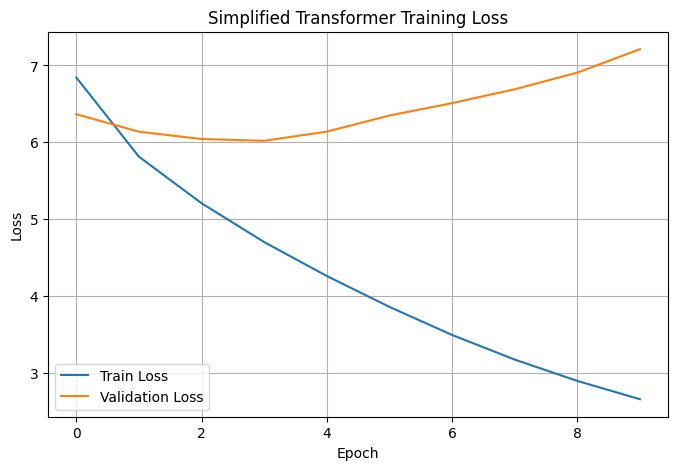

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_tf, label="Train Loss")
plt.plot(val_losses_tf, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simplified Transformer Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
def translate_sentence_transformer(model, sentence, src_vocab, tgt_vocab, idx_to_tgt, device, max_len=20):
    model.eval()

    tokens = ["<sos>"] + tokenize(sentence) + ["<eos>"]
    src_indices = [src_vocab.get(token, src_vocab["<unk>"]) for token in tokens]
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)

    generated = [tgt_vocab["<sos>"]]

    for _ in range(max_len):
        tgt_tensor = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(src_tensor, tgt_tensor)

        next_token = output[:, -1, :].argmax(dim=-1).item()

        if next_token == tgt_vocab["<eos>"]:
            break

        generated.append(next_token)

    tokens_out = [idx_to_tgt[idx] for idx in generated[1:] if idx in idx_to_tgt]
    return tokens_out

In [40]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

references_tf = []
hypotheses_tf = []

for src_indices, tgt_indices in val_pairs:
    src_sentence = " ".join([idx_to_src[idx] for idx in src_indices[1:-1]])
    ref_tokens = [idx_to_tgt[idx] for idx in tgt_indices[1:-1]]
    pred_tokens = translate_sentence_transformer(
        transformer_model, src_sentence, src_vocab, tgt_vocab, idx_to_tgt, device
    )

    references_tf.append([ref_tokens])
    hypotheses_tf.append(pred_tokens)

smooth = SmoothingFunction().method1
bleu_score_tf = corpus_bleu(references_tf, hypotheses_tf, smoothing_function=smooth)

print("Transformer BLEU Score:", bleu_score_tf)

Transformer BLEU Score: 0.018073357334370273


In [42]:
idx = 0
for src_indices, tgt_indices in val_pairs:
    src_sentence = " ".join([idx_to_src[idx] for idx in src_indices[1:-1]])
    ref_sentence = " ".join([idx_to_tgt[idx] for idx in tgt_indices[1:-1]])
    pred_sentence = " ".join(
        translate_sentence_transformer(transformer_model, src_sentence, src_vocab, tgt_vocab, idx_to_tgt, device)
    )

    print("Source:   ", src_sentence)
    print("Reference:", ref_sentence)
    print("Predicted:", pred_sentence)
    print("-" * 50)

    if idx > 10:
        break
    idx += 1

Source:    cest un gros gourdin en bois de chene.
Reference: it was a stout oak cudgel.
Predicted: i have my enemies within my hand over my arms.
--------------------------------------------------
Source:    where got you all these fine feathers, jim?
Reference: où avez-vous pris tout ce beau plumage, jim?
Predicted: où vas-tu, vous êtes cause de moi?
--------------------------------------------------
Source:    and i must cross it with silver, i suppose?
Reference: -- je suppose qu'il faut la croiser avec de l'argent?
Predicted: -- et je crois que je vais aller en montant l'escalier.
--------------------------------------------------
Source:    this is my one chance.
Reference: c'est mon unique chance.
Predicted: -- c'est une chose matérielle
--------------------------------------------------
Source:    helen!
Reference: -- hélène!
Predicted: o!
--------------------------------------------------
Source:    he asked me to show you up at once when you came.
Reference: il ma prié de vous

## Part 4: Simplified Transformer Results and Analysis

I implemented a simplified Transformer model from scratch with the following constraints:
- 2 encoder layers
- 2 decoder layers
- 2 attention heads
- embedding size of 64
- feedforward dimension of 128

### Results

The Transformer training loss decreased from **6.84 to 2.66**, indicating that the model successfully learned patterns from the training data.

However, similar to the seq2seq model, the validation loss increased over time (from **6.36 to 7.21**), indicating overfitting.

Example predictions:
- `do you love me, jane? -> laissez-moi vous le promets, de moi?`
- `what is the meaning of this? -> que diable les bords du chien ?`
- `i am quite sure -> je suis bien que vous avez simplement bouleversé pas paru ?`
- `good night -> bonsoir` (correct)

The model produces more fluent sentence structures than the seq2seq model, but still generates many incorrect or partially coherent translations.


### BLEU Score
**Transformer BLEU = 0.0181**

### Key Differences

1. **Performance**
   - The Transformer achieved a slightly higher BLEU score than the seq2seq model.
   - This indicates better ability to capture relationships between words using attention.

2. **Output Quality**
   - Transformer outputs are generally more structured and fluent.
   - However, both models still produce incorrect or nonsensical translations.

3. **Overfitting**
   - Both models show strong overfitting:
     - training loss ↓
     - validation loss ↑
   - This suggests the dataset is still too complex relative to model size and training setup.

4. **Architecture Advantage**
   - The Transformer uses parallel attention mechanisms instead of recurrence.
   - This allows it to better model long-range dependencies compared to seq2seq.

5. **Runtime**
   - The Transformer trains efficiently due to parallelization.
   - On this dataset, runtime differences were not significant due to small scale.

 

### Conclusion

The simplified Transformer slightly outperformed the seq2seq attention model, achieving a higher BLEU score (**0.0181 vs 0.0131**) and producing more structured outputs. 

However, both models struggled with generalization due to:
- the complexity of the dataset (literary text)
- limited training time
- relatively small model size
